# Blood vessel quantification (binary mask)

This notebook loads **`vessel_quantification.py`**, builds a one-pixel **skeleton** of the foreground, splits the network into **segments between junctions and free tips**, and reports **length** (along the skeleton) and **radius / width** (from the Euclidean distance transform sampled on the skeleton).

**Definitions**

- **Segment (vessel entity)**: a maximal path on the skeleton with no branch in its interior; ends are either **junctions** (degree ≥ 3) or **tips** (degree 1). This is the usual graph view of a vessel tree.
- **“Non-branching” along the segment**: every such segment is non-branching by construction; bifurcations sit at segment ends.
- **Filtering “branching” segments for reporting**:
  - **`terminal_only`**: keep segments that have at least one **free tip** (common choice if you want paths that end in the tissue).
  - **`internal_only`**: keep segments whose **both** ends are junctions (trunk-like links between bifurcations).
  - **`all`**: keep everything.
- **Radius / width**: `scipy.ndimage.distance_transform_edt` on the **binary mask** gives a local half-width; values on the skeleton are summarized (mean / median). Use **`radius_exclude_near_junction_px`** to ignore samples too close to a junction pixel (often stabilizes width away from bifurcations).

Adjust **`min_segment_length_px`**, **`prune_spur_length_px`**, and junction masking to match your resolution and noise level.

In [1]:
%matplotlib inline

from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from vessel_quantification import (
    SegmentFilter,
    analyze_vessel_mask,
    annotate_blob_ids,
    annotate_segment_ids,
    blob_statistics_records,
    load_binary_mask,
    preprocess_mask,
    render_blob_overlay,
    render_segment_overlay,
    segments_to_records,
)

## 1. Paths and parameters

Set **`MASK_PATH`** to your PNG mask (0/255 or 0/1). Optionally set **`PIXEL_SIZE_UM`** for micrometer columns in the table.

In [2]:
MASK_PATH = Path("2ndHoxDex4 #12 10X CB_Bottom Slide_D_p00_0_A01f00d2 seg.png")  # TODO: change to your generated mask
PIXEL_SIZE_UM: float | None = None  # e.g. 0.325 if each pixel is 0.325 µm

SEGMENT_FILTER: SegmentFilter | str = SegmentFilter.ALL
# SEGMENT_FILTER = SegmentFilter.TERMINAL_ONLY
# SEGMENT_FILTER = SegmentFilter.INTERNAL_ONLY

MIN_SEGMENT_LENGTH_PX = 2.0
PRUNE_SPUR_LENGTH_PX = 10.0
RADIUS_EXCLUDE_NEAR_JUNCTION_PX = 5.0
MIN_OBJECT_AREA_PX = 5

## 2. Load mask and optional cleanup

/Users/km4n6/Dropbox/bharath/UMKC_Research/codes/Blood_vessel_Segmentation/vessel_quantification.py:116: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  fg = remove_small_objects(fg, min_size=int(min_object_area_px))


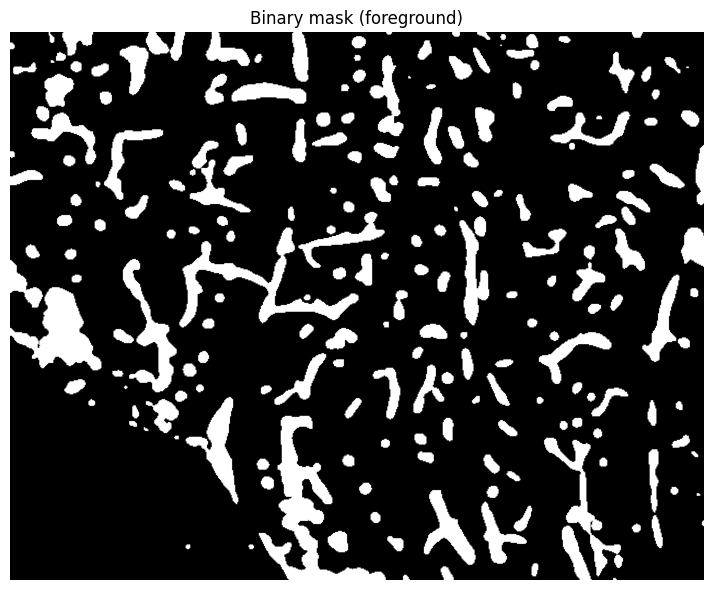

In [3]:
if not MASK_PATH.is_file():
    # Tiny synthetic T-junction for a dry run when no file is present yet
    from scipy.ndimage import binary_dilation

    h, w = 80, 120
    m = np.zeros((h, w), dtype=bool)
    m[h // 2, 10 : w - 10] = True
    m[10 : h - 10, w // 2] = True
    mask = binary_dilation(m, iterations=2)
    print("MASK_PATH not found — using synthetic T-junction mask.")
else:
    mask = load_binary_mask(MASK_PATH)

mask = preprocess_mask(mask, min_object_area_px=MIN_OBJECT_AREA_PX)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.imshow(mask, cmap="gray")
ax.set_title("Binary mask (foreground)")
ax.axis("off")
plt.tight_layout()

## 3. Run analysis

In [4]:
segments, label_image, meta = analyze_vessel_mask(
    mask,
    pixel_size_um=PIXEL_SIZE_UM,
    min_segment_length_px=MIN_SEGMENT_LENGTH_PX,
    segment_filter=SEGMENT_FILTER,
    radius_exclude_near_junction_px=RADIUS_EXCLUDE_NEAR_JUNCTION_PX,
    min_object_area_px=MIN_OBJECT_AREA_PX,
    prune_spur_length_px=PRUNE_SPUR_LENGTH_PX,
)

records = segments_to_records(segments, pixel_size_um=PIXEL_SIZE_UM)
df = pd.DataFrame.from_records(records)
df

,segment_id,length_px,radius_mean_px,radius_median_px,radius_std_px,width_mean_px,width_median_px,degree_end_a,degree_end_b,is_terminal,is_internal,radius_computed_px
0,1,16.071068,2.270820,2.118034,0.378649,4.541641,4.236068,1,3,True,False,10
1,2,10.242641,2.414218,2.236068,0.686695,4.828436,4.472136,1,1,True,False,10
2,3,20.313708,4.558222,4.736068,1.433856,9.116444,9.472136,1,1,True,False,18
3,4,13.313708,4.059907,4.242641,1.231729,8.119814,8.485281,1,3,True,False,7
4,5,46.384776,7.863936,8.062258,1.469187,15.727872,16.124515,1,3,True,False,37
...,...,...,...,...,...,...,...,...,...,...,...,...
852,853,2.414214,0.000000,0.000000,0.000000,0.000000,0.000000,3,3,False,True,0
853,854,16.000000,10.291710,10.198039,0.284081,20.583420,20.396078,3,3,False,True,5
854,855,38.071068,8.088733,7.810250,1.994946,16.177466,15.620499,3,3,False,True,27
855,856,12.656854,4.912455,5.000000,1.313364,9.824911,10.000000,3,1,True,False,7


## 4. Per-blob (connected component) statistics

Each **blob** is one connected white region in the mask (4- or 8-neighborhood; set `BLOB_CONNECTIVITY` below). Every skeleton **segment** is assigned to the blob that contains a plurality of its skeleton pixels (`df["blob_id"]`). The table **`df_blobs`** has one row per blob: foreground **area**, **total skeleton length** (sum of segment lengths), **`max_segment_length_px`** (longest single segment between two nodes), **`centerline_network_diameter_px`** (longest shortest path along the segment graph—longest tip-to-tip style path for a tree), and **length-weighted** mean width/radius across segments.

**2D footprint shape (compact vs elongated):** each blob also gets equivalent-ellipse **`eccentricity_2d`** (0 ≈ circular, higher ≈ elongated in-plane), **`ellipse_axis_major_px`**, **`ellipse_axis_minor_px`**, **`ellipse_axis_ratio`**, **`circularity_2d`** (isoperimetric \(4\pi A / P^2\)), and **`morphology_2d`**: `compact`, `elongated`, `intermediate`, or `degenerate` (tiny blobs). Defaults are set in `blob_statistics_records` (`shape_compact_max_eccentricity`, `shape_elongated_min_eccentricity`, `shape_elongated_min_axis_ratio`); pass those keyword arguments on the call below to tune classification.

In [5]:
from vessel_quantification import blob_statistics_records

BLOB_CONNECTIVITY = 2  # scipy.ndimage: 1 = 4-neighbors, 2 = 8-neighbors

blob_rows, cc_labels, segment_blob_ids = blob_statistics_records(
    segments,
    mask,
    connectivity=BLOB_CONNECTIVITY,
    pixel_size_um=PIXEL_SIZE_UM,
)
df_blobs = pd.DataFrame.from_records(blob_rows)
df["blob_id"] = segment_blob_ids.astype(int)

df_blobs

,blob_id,area_px,n_segments,total_skeleton_length_px,max_segment_length_px,centerline_network_diameter_px,centerline_network_diameter_unmerged_px,centerline_network_diameter_merged_px,width_mean_length_weighted_px,radius_mean_length_weighted_px,width_mean_over_segments_px,width_along_longest_path_px,width_along_longest_unmerged_path_px,width_along_longest_merged_path_px,eccentricity_2d,ellipse_axis_major_px,ellipse_axis_minor_px,ellipse_axis_ratio,circularity_2d,morphology_2d
0,1,139,2,18.485281,19.485281,19.485281,16.071068,19.485281,3.948494,1.974247,2.270820,3.948494,4.541641,3.948494,0.910457,22.003689,9.100795,2.417776,0.563462,elongated
1,2,1609,7,98.941125,78.455844,78.455844,31.899495,78.455844,14.592426,7.296213,8.285438,16.140344,15.959750,16.140344,0.748876,63.843831,42.309970,1.508955,0.483505,intermediate
2,3,1251,6,59.455844,51.870058,51.870058,22.071068,51.870058,13.881063,6.940531,8.405387,15.466612,13.439985,15.466612,0.789232,52.116219,32.004335,1.628411,0.681646,intermediate
3,4,1007,3,54.213203,57.213203,57.213203,46.384776,57.213203,13.456755,6.728378,5.242624,13.456755,15.727872,13.456755,0.935387,61.794587,21.852235,2.827838,0.567872,elongated
4,5,2541,8,121.526912,101.284271,101.284271,44.556349,101.284271,17.000197,8.500099,8.555275,20.566188,21.990785,20.566188,0.882686,97.729853,45.929388,2.127828,0.408469,elongated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,209,313,6,19.485281,22.071068,22.071068,7.828427,22.071068,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.756945,24.937101,16.295861,1.530272,0.750014,intermediate
209,210,269,2,19.485281,20.485281,20.485281,17.071068,20.485281,8.952282,4.476141,5.109163,8.952282,10.218326,8.952282,0.877742,26.946586,12.911018,2.087100,0.739512,elongated
210,211,440,1,24.727922,24.727922,24.727922,24.727922,24.727922,13.233949,6.616975,13.233949,13.233949,13.233949,13.233949,0.816346,31.829048,18.383296,1.731411,0.690538,intermediate
211,212,98,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.654454,13.310586,10.064157,1.322573,0.759080,intermediate


## 5. Per-blob visualization

Colored overlay (one color per blob), numeric **blob_id** at each blob’s centroid, and bar charts for total skeleton length and length-weighted mean width.

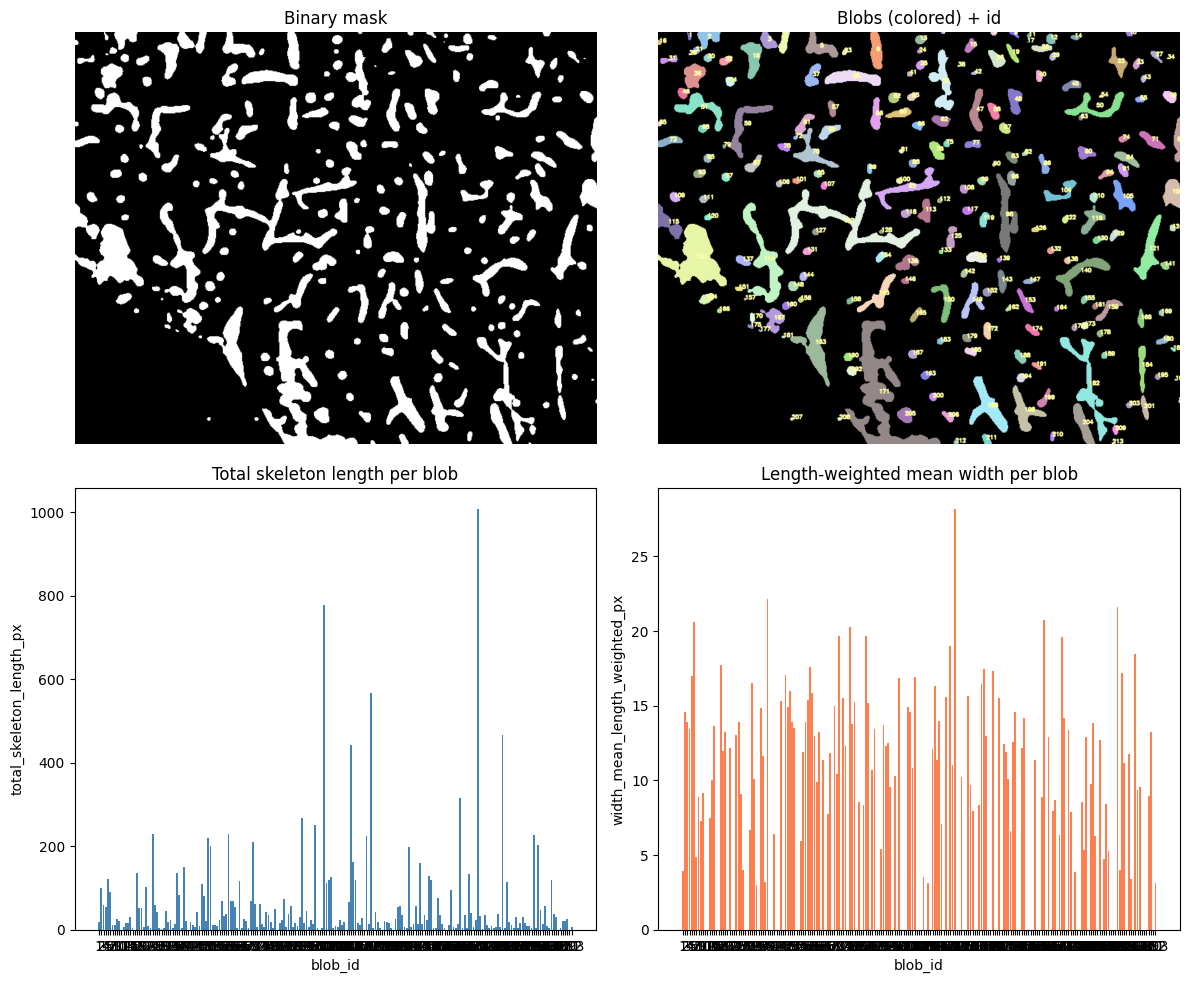

In [6]:
from vessel_quantification import annotate_blob_ids, render_blob_overlay

base_u8 = (mask.astype(np.float32) * 255).astype(np.uint8)
blob_overlay = render_blob_overlay(base_u8, cc_labels, alpha=0.55, cmap_seed=43)
blob_with_ids = annotate_blob_ids(blob_overlay, cc_labels)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(mask, cmap="gray")
axes[0, 0].set_title("Binary mask")
axes[0, 1].imshow(cv2.cvtColor(blob_with_ids, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title("Blobs (colored) + id")

axes[1, 0].bar(df_blobs["blob_id"].astype(str), df_blobs["total_skeleton_length_px"], color="steelblue")
axes[1, 0].set_xlabel("blob_id")
axes[1, 0].set_ylabel("total_skeleton_length_px")
axes[1, 0].set_title("Total skeleton length per blob")

axes[1, 1].bar(df_blobs["blob_id"].astype(str), df_blobs["width_mean_length_weighted_px"], color="coral")
axes[1, 1].set_xlabel("blob_id")
axes[1, 1].set_ylabel("width_mean_length_weighted_px")
axes[1, 1].set_title("Length-weighted mean width per blob")

axes[0, 0].axis("off")
axes[0, 1].axis("off")
plt.tight_layout()

## 6. Visuals: skeleton, junctions, segment colors, IDs

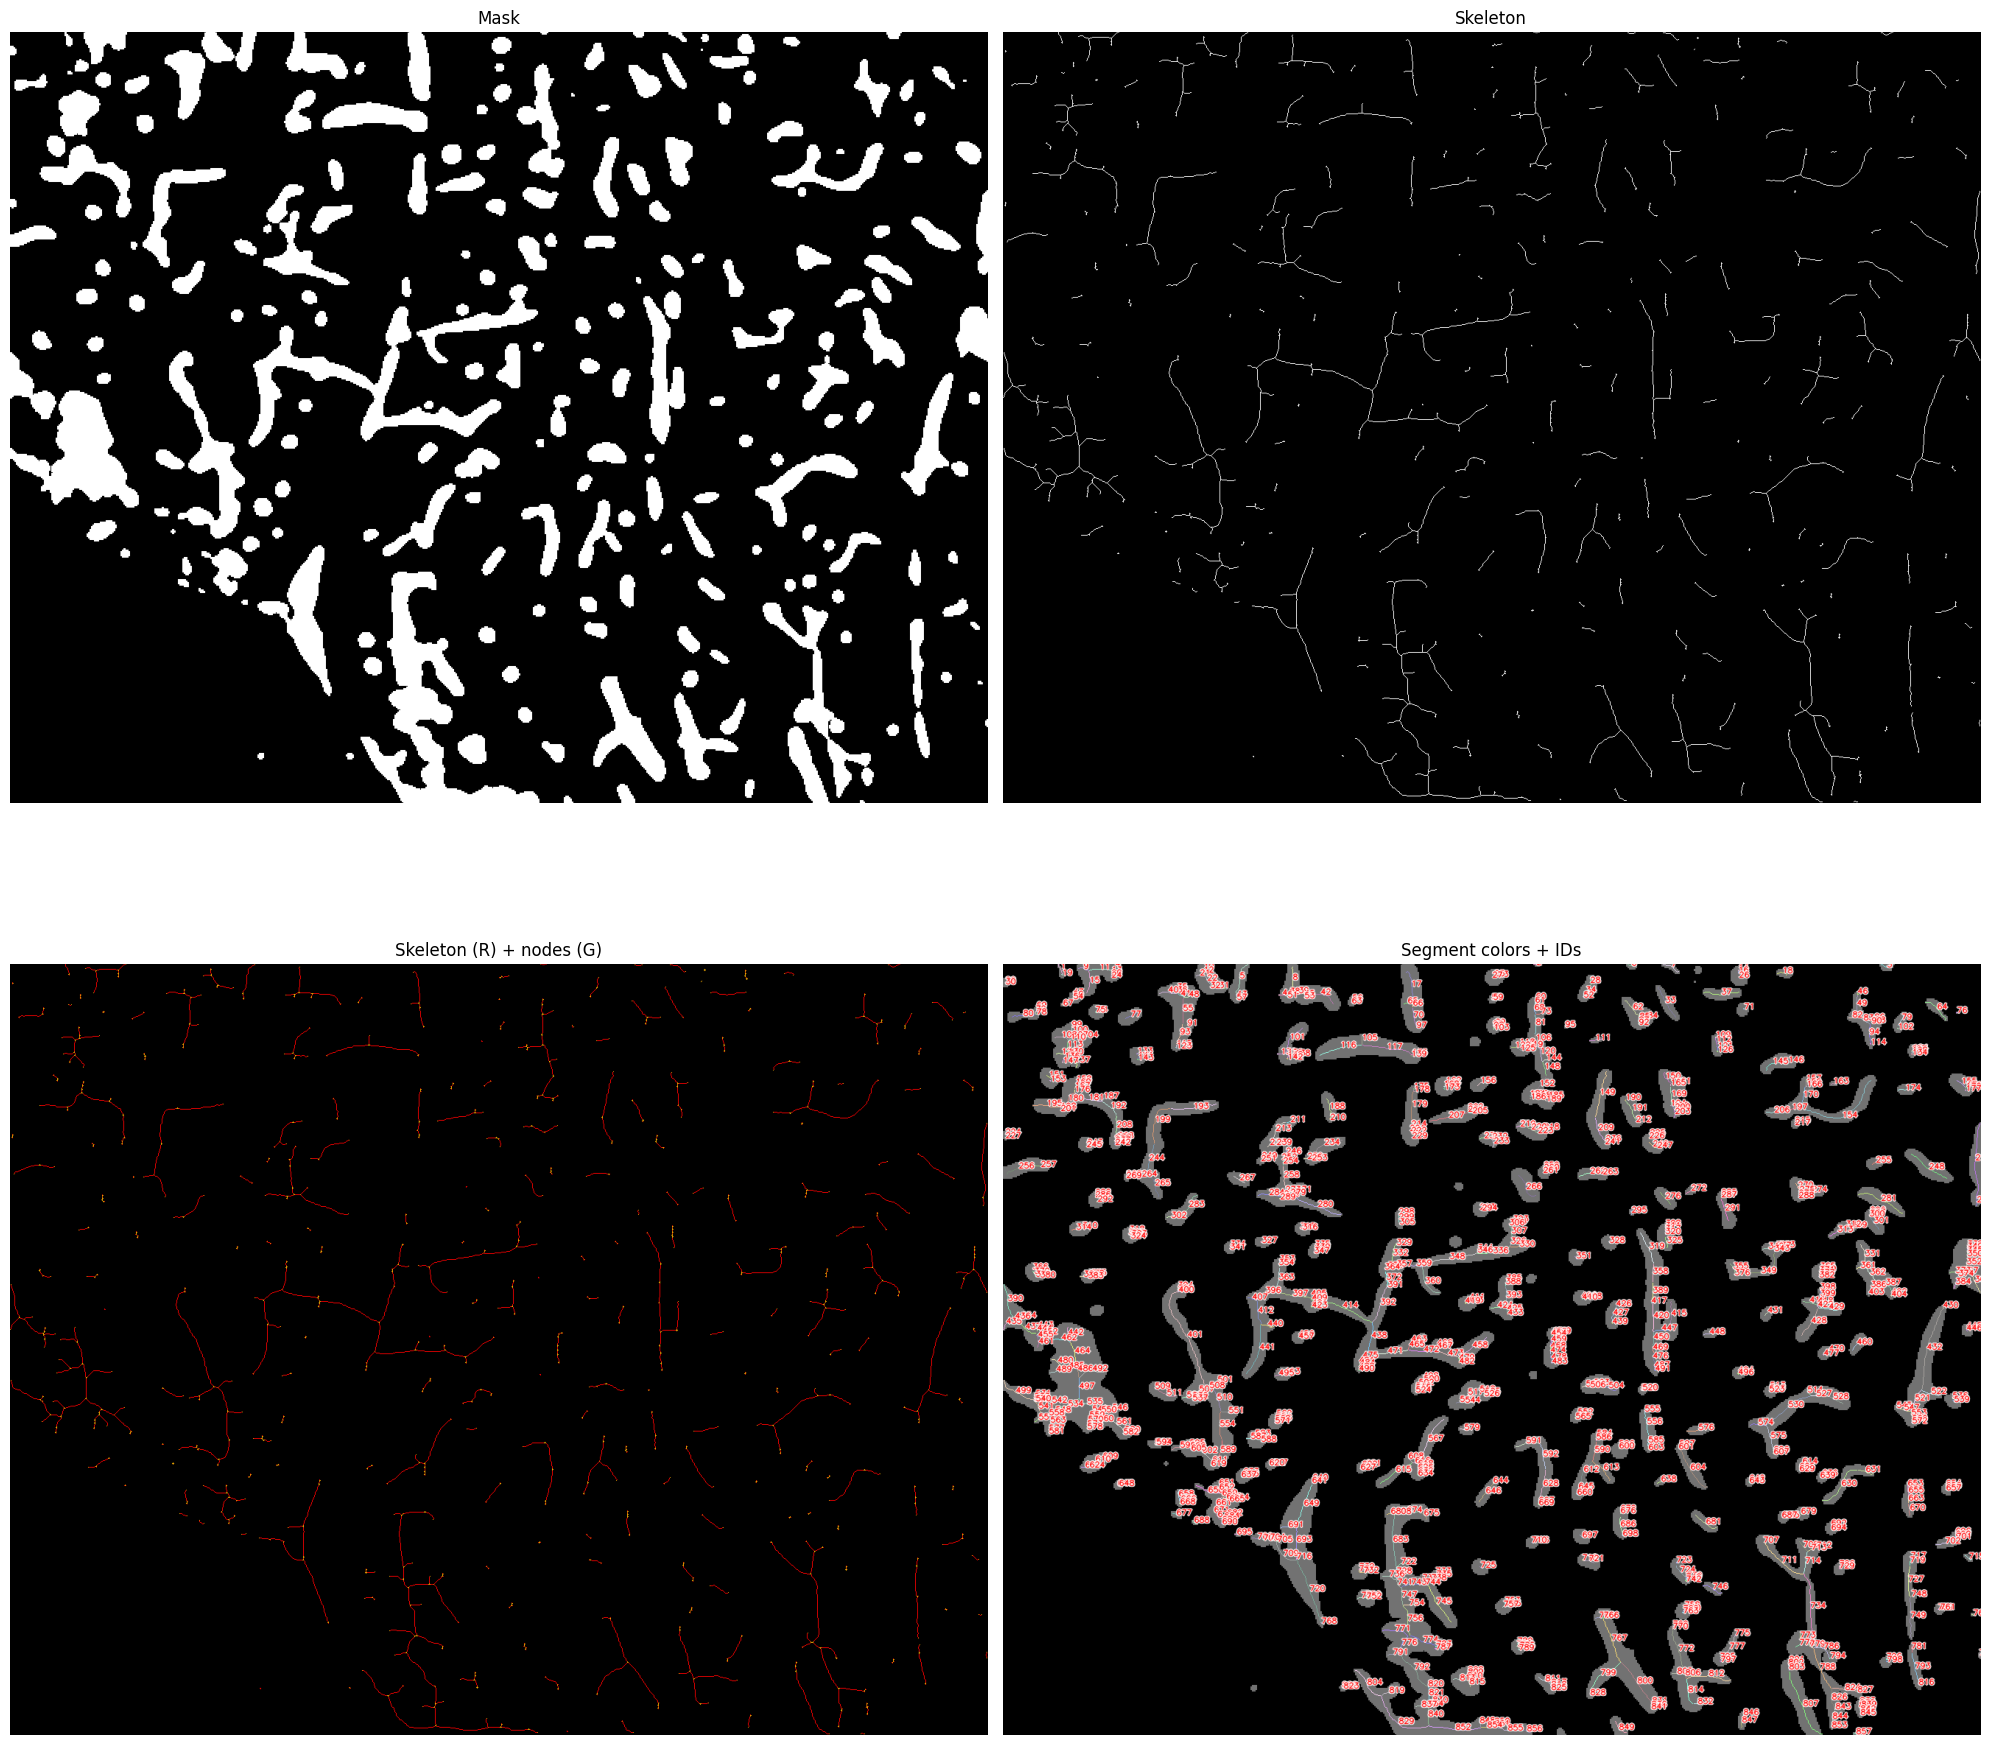

In [7]:
skel = meta["skeleton"]
nodes = meta["node_mask"]
dt = meta["distance_transform"]

base = (mask.astype(np.float32) * 255).astype(np.uint8)
overlay = render_segment_overlay(base, label_image, alpha=0.55, cmap_seed=42)
overlay_ids = annotate_segment_ids(overlay, segments)

fig, axes = plt.subplots(2, 2, figsize=(20, 20))
axes[0, 0].imshow(mask, cmap="gray")
axes[0, 0].set_title("Mask")
axes[0, 1].imshow(skel, cmap="gray")
axes[0, 1].set_title("Skeleton")
axes[1, 0].imshow(np.dstack([skel.astype(float), nodes.astype(float) * 0.7, np.zeros_like(skel)]))
axes[1, 0].set_title("Skeleton (R) + nodes (G)")
axes[1, 1].imshow(cv2.cvtColor(overlay_ids, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title("Segment colors + IDs")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()

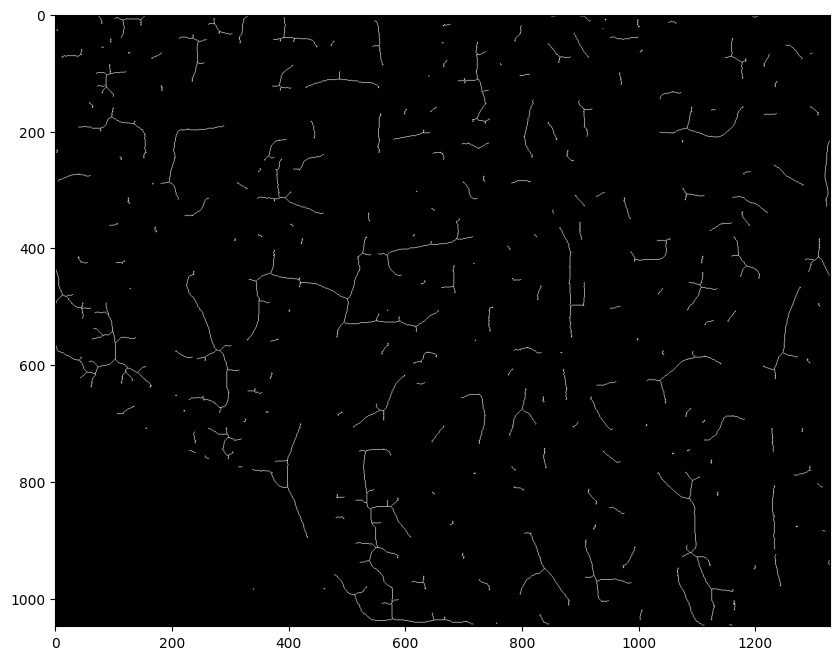

In [8]:
plt.figure(figsize=(10, 10))
plt.imshow(skel, cmap="gray")

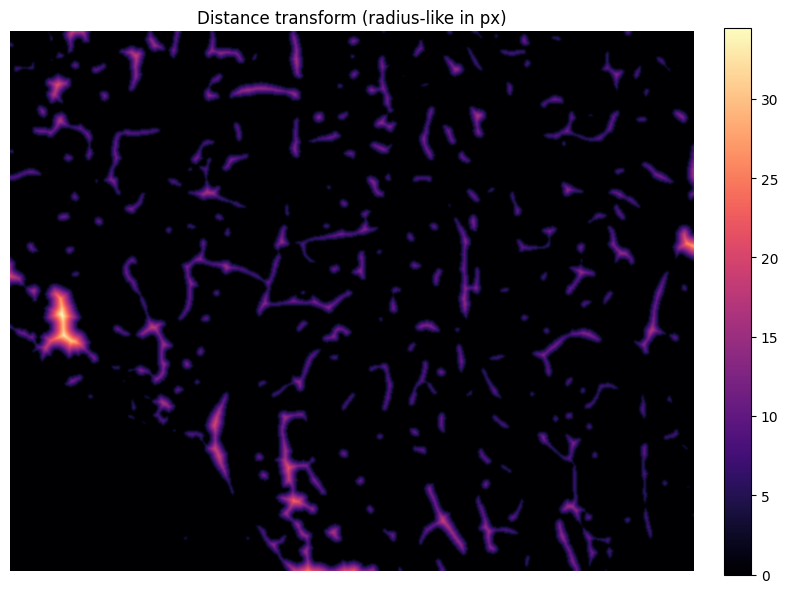

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.imshow(dt, cmap="magma")
ax.set_title("Distance transform (radius-like in px)")
ax.axis("off")
plt.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

## 7. Compare filters (optional)

Toggle **`SEGMENT_FILTER`** in section 1, or run the cell below to print counts side by side.

In [10]:
# for name, filt in [
#     ("all", SegmentFilter.ALL),
#     ("terminal_only", SegmentFilter.TERMINAL_ONLY),
#     ("internal_only", SegmentFilter.INTERNAL_ONLY),
# ]:
#     segs, _, _ = analyze_vessel_mask(
#         mask,
#         min_segment_length_px=MIN_SEGMENT_LENGTH_PX,
#         segment_filter=filt,
#         radius_exclude_near_junction_px=RADIUS_EXCLUDE_NEAR_JUNCTION_PX,
#         prune_spur_length_px=PRUNE_SPUR_LENGTH_PX,
#     )
#     print(f"{name:16s}  n_segments={len(segs)}")

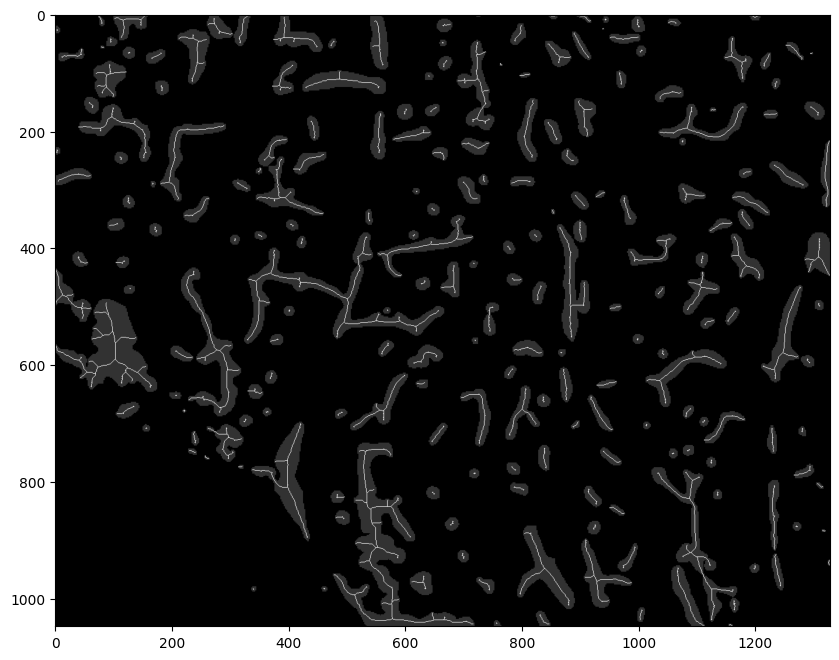

In [11]:
plt.figure(figsize=(10, 10))
plt.imshow(skel, cmap="gray")
plt.imshow(mask, cmap="gray", alpha=0.2)

In [12]:
df[df['length_px'] > 100]

,segment_id,length_px,radius_mean_px,radius_median_px,radius_std_px,width_mean_px,width_median_px,degree_end_a,degree_end_b,is_terminal,is_internal,radius_computed_px,blob_id
153,154,132.296465,7.348582,7.000000,1.630502,14.697164,14.000000,3,3,False,True,103,50
215,216,106.213203,5.876314,5.830952,1.955276,11.752628,11.661904,1,3,True,False,96,64
400,401,157.195959,7.929121,8.062258,2.227638,15.858242,16.124515,3,3,False,True,126,114
431,432,122.012193,10.306817,10.295630,1.311491,20.613635,20.591260,3,3,False,True,101,121
733,734,100.698485,6.335014,7.000000,1.392487,12.670029,14.000000,3,3,False,True,84,182
806,807,106.740115,10.198300,10.816654,2.742883,20.396601,21.633308,3,1,True,False,87,204


(np.float64(-0.5), np.float64(1327.5), np.float64(1047.5), np.float64(-0.5))

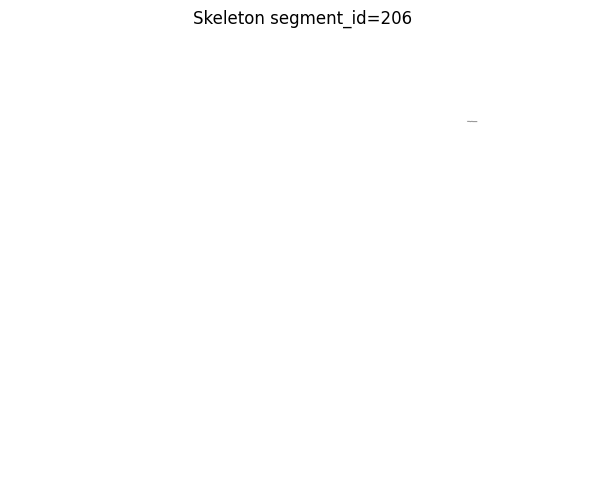

In [13]:
seg = segments[205]  # or pick by segment_id / df row

sk_one = np.zeros_like(mask, dtype=bool)
r, c = seg.path_rc[:, 0], seg.path_rc[:, 1]
sk_one[r, c] = True

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.imshow(sk_one, cmap="gray_r")
ax.set_title(f"Skeleton segment_id={seg.segment_id}")
ax.axis("off")

(np.float64(-0.5), np.float64(1327.5), np.float64(1047.5), np.float64(-0.5))

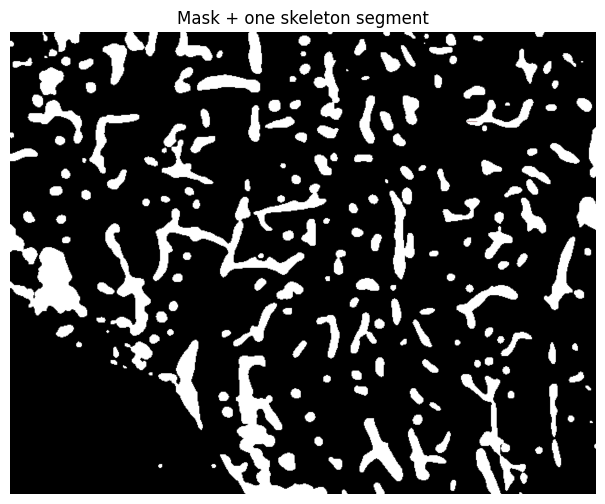

In [14]:
rgba = np.zeros((*mask.shape, 4))
rgba[..., 0] = sk_one.astype(float)  # red skeleton
rgba[..., 3] = sk_one.astype(float) * 0.9

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(mask, cmap="gray")
ax.imshow(rgba)
ax.set_title("Mask + one skeleton segment")
ax.axis("off")

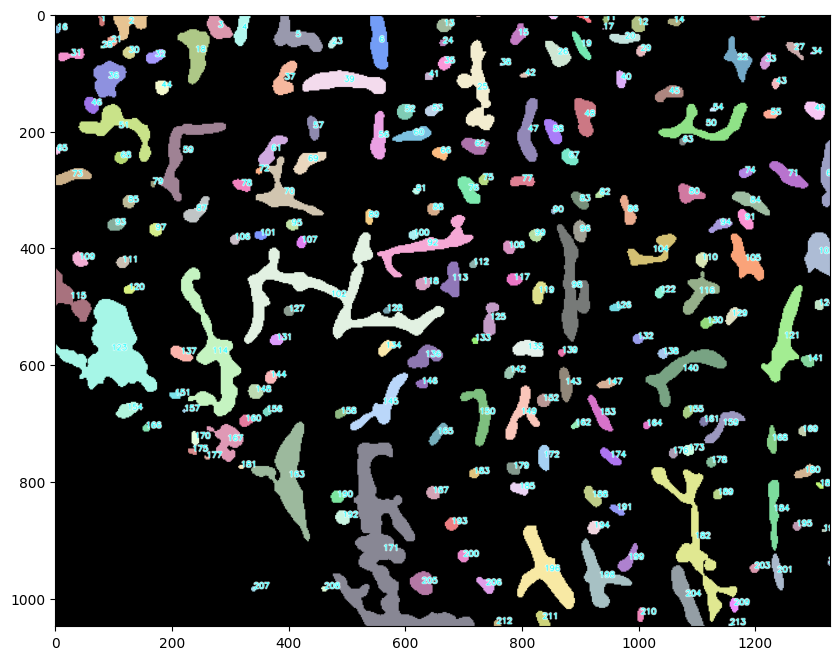

In [15]:
plt.figure(figsize=(10, 10))
plt.imshow(blob_with_ids, cmap="nipy_spectral")

In [16]:
df_blobs[df_blobs['blob_id'] == 206]

,blob_id,area_px,n_segments,total_skeleton_length_px,max_segment_length_px,centerline_network_diameter_px,centerline_network_diameter_unmerged_px,centerline_network_diameter_merged_px,width_mean_length_weighted_px,radius_mean_length_weighted_px,width_mean_over_segments_px,width_along_longest_path_px,width_along_longest_unmerged_path_px,width_along_longest_merged_path_px,eccentricity_2d,ellipse_axis_major_px,ellipse_axis_minor_px,ellipse_axis_ratio,circularity_2d,morphology_2d
205,206,579,4,29.970563,30.970563,30.970563,27.556349,30.970563,9.523939,4.761969,3.442673,9.523939,10.358332,9.523939,0.808464,36.92061,21.729484,1.699102,0.675677,intermediate


(array([146.,  28.,  12.,   7.,   4.,   1.,   1.,   0.,   0.,   2.]),
 array([  2.41421356,  55.37019529, 108.32617701, 161.28215874,
        214.23814046, 267.19412218, 320.15010391, 373.10608563,
        426.06206736, 479.01804908, 531.97403081]),
 <BarContainer object of 10 artists>)

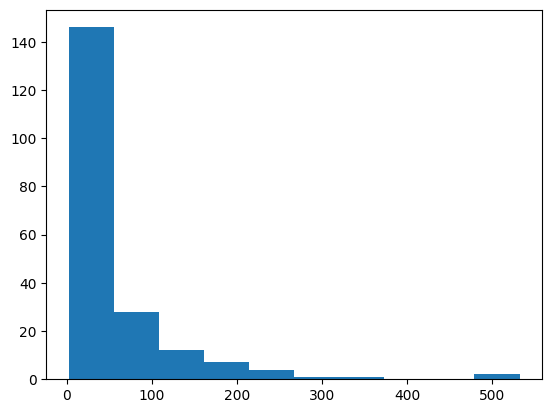

In [17]:
plt.hist(df_blobs[df_blobs['n_segments']!=0]['max_segment_length_px'])

(array([65., 15., 16., 24., 39., 24., 12.,  5.,  0.,  1.]),
 array([ 0.        ,  2.81651229,  5.63302458,  8.44953687, 11.26604916,
        14.08256145, 16.89907374, 19.71558603, 22.53209832, 25.34861061,
        28.1651229 ]),
 <BarContainer object of 10 artists>)

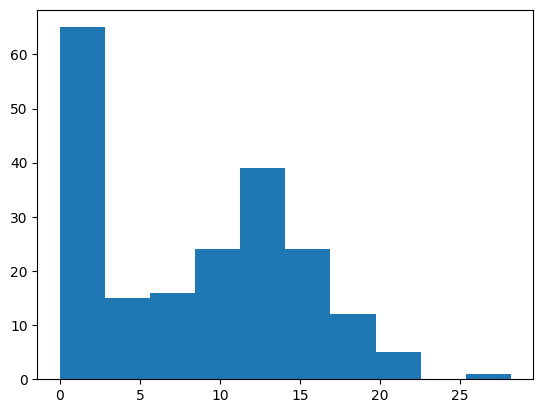

In [18]:
plt.hist(df_blobs[df_blobs['n_segments']!=0]['width_mean_length_weighted_px'])

(array([ 2.,  6.,  8., 27., 54., 53., 31., 22.,  7.,  3.]),
 array([0.95424251, 1.28647363, 1.61870475, 1.95093587, 2.28316699,
        2.61539811, 2.94762923, 3.27986035, 3.61209147, 3.94432259,
        4.27655371]),
 <BarContainer object of 10 artists>)

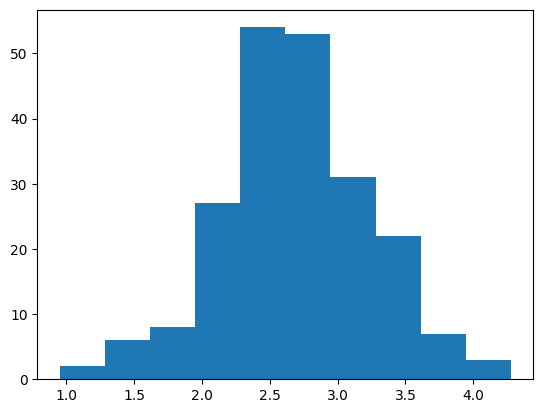

In [19]:
plt.hist(np.log10(df_blobs['area_px']))


In [20]:
compact_blobs = df_blobs[
    (df_blobs["morphology_2d"] != "elongated") &
    (df_blobs["circularity_2d"] > 0.7)
]

not_compact_blobs = df_blobs[
    ((df_blobs["morphology_2d"] == "elongated") |
    (df_blobs["morphology_2d"] == "intermediate")) &
    (df_blobs["area_px"] > 100)
]


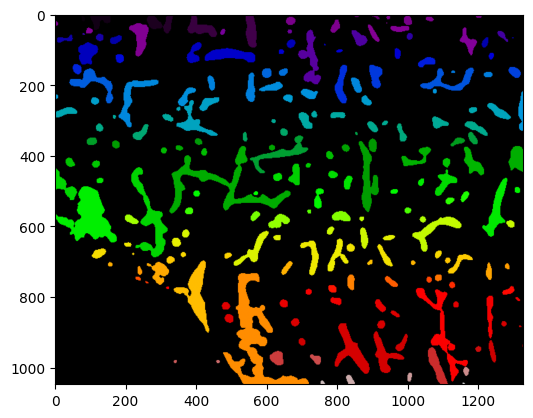

In [21]:
plt.imshow(cc_labels, cmap="nipy_spectral")

In [22]:
from copy import deepcopy

def get_blob_specific_mask(mask, blob_id_list):
    blob_mask = np.zeros_like(mask, dtype=int)
    for blob_id in blob_id_list:
        blob_mask[cc_labels == blob_id] = blob_id
    return blob_mask


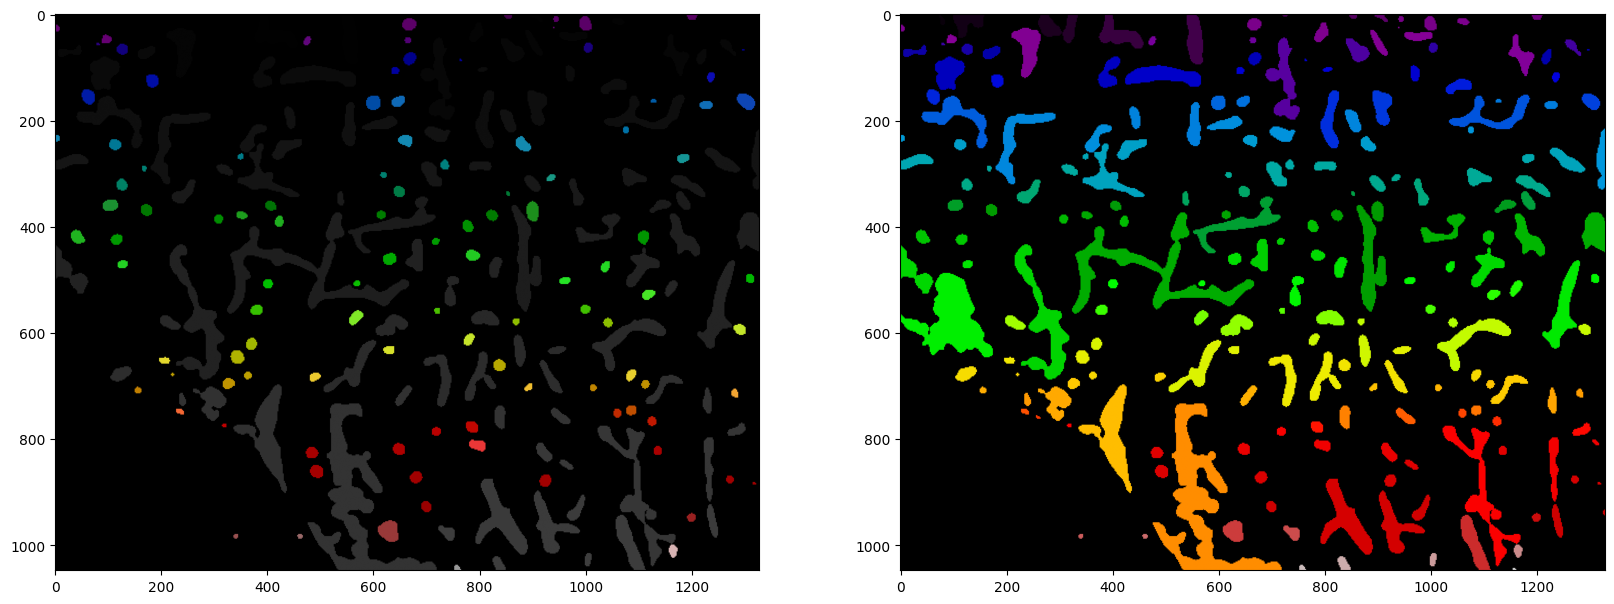

In [23]:
compact_blob_mask = get_blob_specific_mask(mask, list(compact_blobs['blob_id']))
not_compact_blob_mask = get_blob_specific_mask(mask, list(not_compact_blobs['blob_id']))

fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(compact_blob_mask, cmap="nipy_spectral")
ax[0].imshow(not_compact_blob_mask, cmap="gray", alpha=0.25)
ax[1].imshow(cc_labels, cmap="nipy_spectral")

In [24]:
def clean_length_width_for_plot(
    df: pd.DataFrame,
    area_col: str = "area_px",
    length_col: str = "max_segment_length_px",
    width_col: str = "width_along_longest_merged_path_px",
    out_length_col: str = "length_clean",
    out_width_col: str = "width_clean",
):
    """
    Returns a copy of df with cleaned length/width columns for plotting only.

    Rules:
    1) If length == 0 and width == 0 and area > 0:
       set length = width = sqrt(area/pi)   (circle approximation)
    2) If length > 0 and width == 0:
       set width = length
    """
    out = df.copy()

    # Start from original values
    out[out_length_col] = out[length_col].astype(float)
    out[out_width_col] = out[width_col].astype(float)

    # Rule 1: both zero, non-zero area -> circle-equivalent radius/diameter proxy
    both_zero = (
        (out[out_length_col] == 0)
        & (out[out_width_col] == 0)
        & (out[area_col] > 0)
    )
    eq = np.sqrt(out.loc[both_zero, area_col] / np.pi)
    out.loc[both_zero, out_length_col] = eq
    out.loc[both_zero, out_width_col] = eq

    # Rule 2: non-zero length, zero width -> width = length
    width_zero_len_nonzero = (
        (out[out_length_col] > 0)
        & (out[out_width_col] == 0)
    )
    out.loc[width_zero_len_nonzero, out_width_col] = out.loc[
        width_zero_len_nonzero, out_length_col
    ]

    return out

In [25]:
compact_clean = clean_length_width_for_plot(compact_blobs)
not_compact_clean = clean_length_width_for_plot(not_compact_blobs)

In [26]:
compact_clean

,blob_id,area_px,n_segments,total_skeleton_length_px,max_segment_length_px,centerline_network_diameter_px,centerline_network_diameter_unmerged_px,centerline_network_diameter_merged_px,width_mean_length_weighted_px,radius_mean_length_weighted_px,...,width_along_longest_unmerged_path_px,width_along_longest_merged_path_px,eccentricity_2d,ellipse_axis_major_px,ellipse_axis_minor_px,ellipse_axis_ratio,circularity_2d,morphology_2d,length_clean,width_clean
7,8,119,1,10.828427,10.828427,10.828427,10.828427,10.828427,8.908536,4.454268,...,8.908536,8.908536,0.794718,16.082354,9.761657,1.647503,0.819011,intermediate,10.828427,8.908536
9,10,191,1,20.313708,20.313708,20.313708,20.313708,20.313708,9.116444,4.558222,...,9.116444,9.116444,0.805672,20.940477,12.404350,1.688156,0.729916,intermediate,20.313708,9.116444
10,11,97,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.388635,11.700736,10.780962,1.085315,0.827401,compact,5.556623,5.556623
11,12,509,3,7.242641,13.242641,13.242641,2.828427,13.242641,0.000000,0.000000,...,0.000000,0.000000,0.609624,28.780260,22.813851,1.261526,0.833788,compact,13.242641,13.242641
12,13,501,3,15.071068,17.307136,17.307136,12.656854,17.307136,7.475850,3.737925,...,8.901821,7.475850,0.524756,27.435041,23.354149,1.174740,0.831191,compact,17.307136,7.475850
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,205,1215,5,38.313708,32.485281,32.485281,19.242641,32.485281,9.352451,4.676226,...,18.621514,12.764997,0.491185,42.811621,37.291298,1.148032,0.784901,compact,32.485281,12.764997
206,207,69,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.461574,10.023958,8.892270,1.127266,0.882046,compact,4.686511,4.686511
207,208,79,2,4.828427,4.828427,2.414214,2.414214,2.414214,0.000000,0.000000,...,0.000000,0.000000,0.487847,10.856720,9.477146,1.145568,0.829718,compact,4.828427,4.828427
208,209,313,6,19.485281,22.071068,22.071068,7.828427,22.071068,0.000000,0.000000,...,0.000000,0.000000,0.756945,24.937101,16.295861,1.530272,0.750014,intermediate,22.071068,22.071068


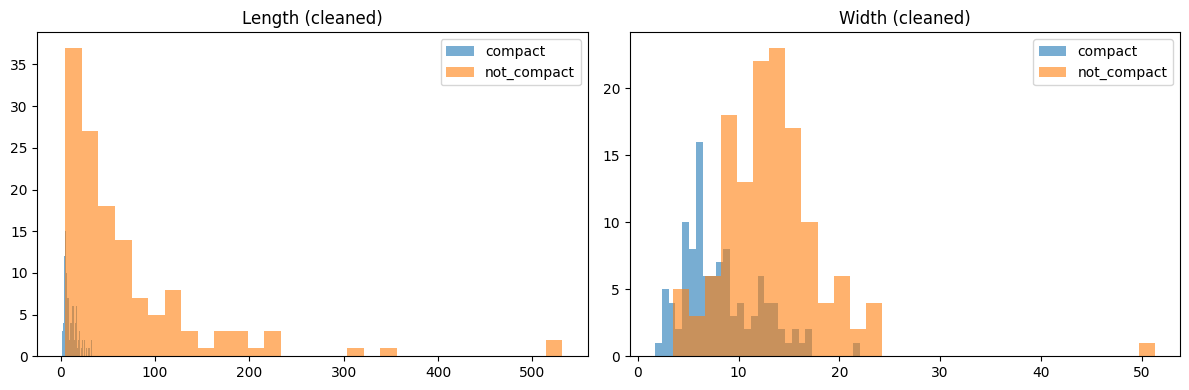

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(compact_clean["length_clean"], bins=30, alpha=0.6, label="compact")
ax[0].hist(not_compact_clean["length_clean"], bins=30, alpha=0.6, label="not_compact")
ax[0].set_title("Length (cleaned)")
ax[0].legend()

ax[1].hist(compact_clean["width_clean"], bins=30, alpha=0.6, label="compact")
ax[1].hist(not_compact_clean["width_clean"], bins=30, alpha=0.6, label="not_compact")
ax[1].set_title("Width (cleaned)")
ax[1].legend()

plt.tight_layout()
plt.show()

(array([23., 29., 22., 20., 10.,  2.,  1.,  0.,  0.,  1.]),
 array([   9. ,  129.6,  250.2,  370.8,  491.4,  612. ,  732.6,  853.2,
         973.8, 1094.4, 1215. ]),
 <BarContainer object of 10 artists>)

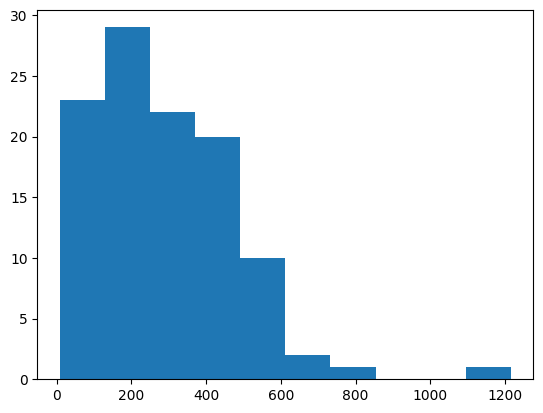

In [28]:
plt.hist(compact_clean['area_px'])